In [ ]:
!pip install transformers==3.0.2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.4/97.4 kB 3.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 769.0/769.0 kB 18.4 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 897.5/897.5 kB 45.4 MB/s eta 0:00:00
  error: subprocess-exited-with-error
  
  × Building wheel for tokenizers (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [59 lines of output]
      /tmp/pip-build-env-ywg1e6ey/overlay/lib/python3.10/site-packages/setuptools/dist.py:332: InformationOnly: Normalizing '0.8.1.rc1' to '0.8.1rc1'
        self.metadata.version = self._normalize_version(self.metadata.version)
      /tmp/pip-build-env-ywg1e6ey/overlay/lib/python3.10/site-packages/setuptools/dist.py:759: SetuptoolsDeprecationWarning: License classifiers ar

In [ ]:
import pandas as pd
from sklearn.utils import resample

# Load the dataset
df = pd.read_csv('/kaggle/input/skills-updated-upsampled-data/Skills Updated upsampled_data.csv')  # Replace with your dataset's file name

# Map scores to labels
def map_scores(score):
    if score in [4, 5]:
        return 2  # Positive
    elif score in [1, 2]:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral

df['Skills_Label'] = df['Skills'].apply(map_scores)  # Replace 'Your_Score_Column' with the actual column name

# Separate the dataset by label
df_0 = df[df['Skills_Label'] == 0]
df_1 = df[df['Skills_Label'] == 1]
df_2 = df[df['Skills_Label'] == 2]

# Perform upsampling
target_size = 3688  # Target size for each label

df_0_upsampled = resample(df_0, replace=True, n_samples=target_size, random_state=42)
df_1_upsampled = resample(df_1, replace=True, n_samples=target_size, random_state=42)
df_2_upsampled = resample(df_2, replace=True, n_samples=target_size, random_state=42)

# Combine the upsampled dataframes
df_balanced = pd.concat([df_0_upsampled, df_1_upsampled, df_2_upsampled])

# Shuffle the dataset
df_balanced = df_balanced.sample(frac=1, random_state=42).reset_index(drop=True)

# Save the balanced dataset to the working directory
df_balanced.to_csv('balanced_dataset.csv', index=False)

print(f"Balanced dataset saved as 'balanced_dataset.csv' in the working directory.")


Balanced dataset saved as 'balanced_dataset.csv' in the working directory.


In [ ]:

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import torch
import seaborn as sns
import transformers
import json
from tqdm import tqdm
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaModel, RobertaTokenizer
import logging
logging.basicConfig(level=logging.ERROR)

from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [ ]:

from torch import cuda
device = 'cuda' if cuda.is_available() else 'cpu'

In [ ]:
import pandas as pd

dataset_path = "/kaggle/working/balanced_dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully!")
df.head()


Dataset Loaded Successfully!


,Combined,Skills,Skills_Label
0,"Docker Products, REST APIs, Kubernetes, Amazon...",5,2
1,Java\nJavaFX\nC++\nC\nHTML\nCascading Style Sh...,5,2
2,Web Design\n3 endorsements\nDatabase Design\n1...,4,2
3,Elastic Stack (ELK)\nSenior Software Engineer ...,3,1
4,"Docker Products, REST APIs, Kubernetes, Amazon...",5,2


In [ ]:
# Create the labels based on Skills score
def map_labels(score):
    if score == 1 or score == 2:
        return 0  # Negative
    elif score == 3:
        return 1  # Neutral
    elif score == 4 or score == 5:
        return 2  # Positive

# Apply the mapping function to the 'Skills' column
df['Skills_Label'] = df['Skills'].apply(map_labels)

print("Mapped Skills Labels:")
print(df['Skills_Label'].value_counts())

print(df.head())

df.to_csv('/kaggle/working/skills_labels.csv', index=False)


Mapped Skills Labels:
Skills_Label
2    3688
1    3688
0    3688
Name: count, dtype: int64
                                            Combined  Skills  Skills_Label
0  Docker Products, REST APIs, Kubernetes, Amazon...       5             2
1  Java\nJavaFX\nC++\nC\nHTML\nCascading Style Sh...       5             2
2  Web Design\n3 endorsements\nDatabase Design\n1...       4             2
3  Elastic Stack (ELK)\nSenior Software Engineer ...       3             1
4  Docker Products, REST APIs, Kubernetes, Amazon...       5             2


In [ ]:

from transformers import RobertaTokenizer
import pandas as pd
from sklearn.model_selection import train_test_split

# Load the tokenizer
tokenizer = RobertaTokenizer.from_pretrained('roberta-base')

df = pd.read_csv("/kaggle/working/skills_labels.csv")



# Function to tokenize the text using RoBERTa tokenizer
def tokenize_function(text):
    return tokenizer(
        text,
        padding='max_length',
        truncation=True,
        max_length=256,
        return_tensors='pt'
    )

# Apply tokenization to the 'Combined' column
df['tokenized'] = df['Combined'].apply(lambda x: tokenize_function(x))

print(df['tokenized'].head())
print(df[['Combined', 'Skills_Label']].head())


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


0    [input_ids, attention_mask]
1    [input_ids, attention_mask]
2    [input_ids, attention_mask]
3    [input_ids, attention_mask]
4    [input_ids, attention_mask]
Name: tokenized, dtype: object
                                            Combined  Skills_Label
0  Docker Products, REST APIs, Kubernetes, Amazon...             2
1  Java\nJavaFX\nC++\nC\nHTML\nCascading Style Sh...             2
2  Web Design\n3 endorsements\nDatabase Design\n1...             2
3  Elastic Stack (ELK)\nSenior Software Engineer ...             1
4  Docker Products, REST APIs, Kubernetes, Amazon...             2


In [ ]:

import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv("/kaggle/working/skills_labels.csv")  # This is your labeled data file


# Split the data into training (80%), validation (10%), and test (10%) sets
train_data, temp_data = train_test_split(df, test_size=0.2, random_state=42)
val_data, test_data = train_test_split(temp_data, test_size=0.5, random_state=42)

print(f"Training Data Shape: {train_data.shape}")
print(f"Validation Data Shape: {val_data.shape}")
print(f"Test Data Shape: {test_data.shape}")


output_dir = "/kaggle/working/"

train_data.to_csv(f"{output_dir}train_data.csv", index=False)
val_data.to_csv(f"{output_dir}val_data.csv", index=False)
test_data.to_csv(f"{output_dir}test_data.csv", index=False)


print(f"Files saved to {output_dir}:")
print("train_data.csv")
print("val_data.csv")
print("test_data.csv")


Training Data Shape: (8851, 3)
Validation Data Shape: (1106, 3)
Test Data Shape: (1107, 3)
Files saved to /kaggle/working/:
train_data.csv
val_data.csv
test_data.csv


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import RobertaTokenizer

#  Define the custom PyTorch Dataset
class SkillsDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length=256):
        self.data = dataframe
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # Get the combined text and label (Skills_Label) for a specific index
        text = str(self.data.iloc[idx]['Combined'])
        label = self.data.iloc[idx]['Skills_Label']


        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt',
            return_token_type_ids=True
        )

        # Extract the tensors from the encoding dictionary and squeeze the batch dimension
        input_ids = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        token_type_ids = encoding['token_type_ids'].squeeze(0)

        return {
            'input_ids': input_ids,
            'attention_mask': attention_mask,
            'token_type_ids': token_type_ids,
            'labels': torch.tensor(label, dtype=torch.long)
        }

train_dataset = SkillsDataset(train_data, tokenizer)
val_dataset = SkillsDataset(val_data, tokenizer)


train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)

# Check a batch from the train DataLoader

for batch in train_dataloader:
    print(f"Input IDs: {batch['input_ids']}")
    print(f"Attention Mask: {batch['attention_mask']}")
    print(f"Token Type IDs: {batch['token_type_ids']}")
    print(f"Labels: {batch['labels']}")
    break  # Just to check one batch


Input IDs: tensor([[    0, 48659, 50118,  ...,     1,     1,     1],
        [    0, 39599, 28023,  ..., 50118, 28588,     2],
        [    0, 50118, 40118,  ..., 13746, 50118,     2],
        ...,
        [    0,  1000,   424,  ..., 16410, 20643,     2],
        [    0, 44051, 20142,  ..., 35495, 50118,     2],
        [    0,  1000,   424,  ..., 16410, 20643,     2]])
Attention Mask: tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1]])
Token Type IDs: tensor([[0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        ...,
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0],
        [0, 0, 0,  ..., 0, 0, 0]])
Labels: tensor([2, 2, 0, 0, 1, 1, 2, 0, 2, 0, 2, 2, 2, 0, 1, 0])


In [ ]:
import torch
import torch.nn as nn
from torch.optim import AdamW
from transformers import RobertaForSequenceClassification

# Define the RoBERTa-based model
class RobertaClass(nn.Module):
    def __init__(self, num_labels=3):
        super(RobertaClass, self).__init__()

        self.roberta = RobertaForSequenceClassification.from_pretrained(
            "roberta-base",   # or "roberta-large"
            num_labels=num_labels,
            ignore_mismatched_sizes=True  # Fixes classifier size mismatch if needed
        )

    def forward(self, input_ids, attention_mask):
        # Forward pass through RoBERTa
        output = self.roberta(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        return output.logits

# Initialize the model
model = RobertaClass(num_labels=3)  # Negative (0), Neutral (1), Positive (2)

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = AdamW(model.parameters(), lr=2e-5)

# Print model summary
print(model)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


RobertaClass(
  (roberta): RobertaForSequenceClassification(
    (roberta): RobertaModel(
      (embeddings): RobertaEmbeddings(
        (word_embeddings): Embedding(50265, 768, padding_idx=1)
        (position_embeddings): Embedding(514, 768, padding_idx=1)
        (token_type_embeddings): Embedding(1, 768)
        (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0.1, inplace=False)
      )
      (encoder): RobertaEncoder(
        (layer): ModuleList(
          (0-11): 12 x RobertaLayer(
            (attention): RobertaAttention(
              (self): RobertaSdpaSelfAttention(
                (query): Linear(in_features=768, out_features=768, bias=True)
                (key): Linear(in_features=768, out_features=768, bias=True)
                (value): Linear(in_features=768, out_features=768, bias=True)
                (dropout): Dropout(p=0.1, inplace=False)
              )
              (output): RobertaSelfOutput(
                (den

In [ ]:
!pip install peft --quiet
!pip install accelerate --quiet


In [ ]:
import pandas as pd
import torch
from torch.utils.data import DataLoader, Dataset, RandomSampler, SequentialSampler
from transformers import RobertaTokenizerFast, RobertaForSequenceClassification, AdamW, get_linear_schedule_with_warmup
import torch.nn as nn
from sklearn.model_selection import train_test_split

# --------------------------
# Custom Dataset
# --------------------------
class TextDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = self.texts[item]
        label = self.labels[item]

        encoding = self.tokenizer.encode_plus(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# --------------------------
# Load data
# --------------------------
texts = df['Combined'].tolist()
labels = df['Skills_Label'].tolist()

train_texts, val_texts, train_labels, val_labels = train_test_split(
    texts, labels, test_size=0.2, random_state=42
)

# --------------------------
# Tokenizer
# --------------------------
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

train_dataset = TextDataset(train_texts, train_labels, tokenizer, max_len=256)
val_dataset = TextDataset(val_texts, val_labels, tokenizer, max_len=256)

train_dataloader = DataLoader(train_dataset, sampler=RandomSampler(train_dataset), batch_size=8)
val_dataloader = DataLoader(val_dataset, sampler=SequentialSampler(val_dataset), batch_size=8)

# --------------------------
# Model
# --------------------------
model = RobertaForSequenceClassification.from_pretrained(
    'roberta-base', num_labels=3, output_attentions=False, output_hidden_states=False
)

# Freeze all layers except classifier
for name, param in model.named_parameters():
    if "classifier" not in name:
        param.requires_grad = False

# Move model to 2 GPUs if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs")
    model = nn.DataParallel(model)
model.to(device)

# --------------------------
# Optimizer & Scheduler
# --------------------------
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5, weight_decay=0.01)

total_steps = len(train_dataloader) * 19
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),  # 10% warmup
    num_training_steps=total_steps
)

criterion = nn.CrossEntropyLoss()

# --------------------------
# Training & Evaluation
# --------------------------
def train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, scheduler, epochs=10):
    best_val_loss = float('inf')
    patience = 3
    patience_counter = 0

    for epoch in range(epochs):
        # Gradually unfreeze some layers every 5 epochs
        if epoch == 5:
            for name, param in model.named_parameters():
                if "encoder.layer.11" in name:  # unfreeze last encoder layer
                    param.requires_grad = True
        if epoch == 10:
            for name, param in model.named_parameters():
                if "encoder.layer.10" in name:
                    param.requires_grad = True
        if epoch == 15:
            for name, param in model.named_parameters():
                if "encoder.layer.9" in name:
                    param.requires_grad = True

        # Training
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for batch in train_dataloader:
            optimizer.zero_grad()
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()
            scheduler.step()

            running_loss += loss.item()
            _, predicted = torch.max(logits, dim=1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        avg_train_loss = running_loss / len(train_dataloader)
        train_accuracy = correct_train / total_train

        # Validation
        model.eval()
        running_val_loss = 0.0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch in val_dataloader:
                input_ids = batch['input_ids'].to(device)
                attention_mask = batch['attention_mask'].to(device)
                labels = batch['labels'].to(device)

                logits = model(input_ids=input_ids, attention_mask=attention_mask).logits
                loss = criterion(logits, labels)
                running_val_loss += loss.item()
                _, predicted = torch.max(logits, dim=1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        avg_val_loss = running_val_loss / len(val_dataloader)
        val_accuracy = correct_val / total_val

        print(f"Epoch {epoch+1}/{epochs}")
        print(f"Training Loss: {avg_train_loss:.4f}, Training Accuracy: {train_accuracy:.4f}")
        print(f"Validation Loss: {avg_val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

# --------------------------
# Start training
# --------------------------
train_and_evaluate(model, train_dataloader, val_dataloader, optimizer, criterion, scheduler, epochs=18)


/opt/conda/lib/python3.10/site-packages/transformers/tokenization_utils_base.py:1617: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be deprecated in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(
Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Using 2 GPUs


/opt/conda/lib/python3.10/site-packages/transformers/optimization.py:591: FutureWarning: This implementation of AdamW is deprecated and will be removed in a future version. Use the PyTorch implementation torch.optim.AdamW instead, or set `no_deprecation_warning=True` to disable this warning
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


Epoch 1/18
Training Loss: 1.0906, Training Accuracy: 0.3953
Validation Loss: 1.0626, Validation Accuracy: 0.6936
Epoch 2/18
Training Loss: 1.0164, Training Accuracy: 0.5943
Validation Loss: 0.9588, Validation Accuracy: 0.6530
Epoch 3/18
Training Loss: 0.8941, Training Accuracy: 0.6495
Validation Loss: 0.8401, Validation Accuracy: 0.6864
Epoch 4/18
Training Loss: 0.7990, Training Accuracy: 0.6930
Validation Loss: 0.7540, Validation Accuracy: 0.7361
Epoch 5/18
Training Loss: 0.7352, Training Accuracy: 0.7287
Validation Loss: 0.6930, Validation Accuracy: 0.7628
Epoch 6/18
Training Loss: 0.6893, Training Accuracy: 0.7420
Validation Loss: 0.6483, Validation Accuracy: 0.8052
Epoch 7/18
Training Loss: 0.6538, Training Accuracy: 0.7622
Validation Loss: 0.6141, Validation Accuracy: 0.7564
Epoch 8/18
Training Loss: 0.6239, Training Accuracy: 0.7772
Validation Loss: 0.5836, Validation Accuracy: 0.8084
Epoch 9/18
Training Loss: 0.6043, Training Accuracy: 0.7861
Validation Loss: 0.5583, Validation 

In [ ]:
# Saving the trained model and tokenizer
def save_model_and_tokenizer(model, tokenizer, model_path='roberta_model.pth', tokenizer_path='roberta_tokenizer'):
    # Save the model's state_dict
    torch.save(model.state_dict(), model_path)
    print(f"Model saved to {model_path}")


    tokenizer.save_pretrained(tokenizer_path)
    print(f"Tokenizer saved to {tokenizer_path}")


save_model_and_tokenizer(model, tokenizer)

Model saved to roberta_model.pth
Tokenizer saved to roberta_tokenizer


In [ ]:
import torch
from sklearn.metrics import classification_report, hamming_loss
import numpy as np


def evaluate_model(model, val_dataloader, device):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits  # ✅ Extract logits from SequenceClassifierOutput

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Store probabilities
            probs = torch.softmax(logits, dim=1)
            all_probs.extend(probs.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)

    # Check the number of unique labels in the predicted labels
    unique_labels = np.unique(all_labels)
    print(f"Unique Labels: {unique_labels}")

    # Set the correct number of classes and target names
    num_classes = len(unique_labels)
    target_names = [f"Class {i}" for i in unique_labels]

    # Classification Report
    print("Classification Report:")
    print(classification_report(all_labels, all_preds, target_names=target_names))

    # Hamming Loss
    hamming = hamming_loss(all_labels, all_preds)
    print(f"Hamming Loss: {hamming:.4f}")


# ✅ Run evaluation
evaluate_model(model, val_dataloader, device)


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


Unique Labels: [0 1 2]
Classification Report:
              precision    recall  f1-score   support

     Class 0       0.86      0.93      0.89       735
     Class 1       0.82      0.82      0.82       752
     Class 2       0.96      0.88      0.92       726

    accuracy                           0.87      2213
   macro avg       0.88      0.88      0.88      2213
weighted avg       0.88      0.87      0.88      2213

Hamming Loss: 0.1252


/opt/conda/lib/python3.10/site-packages/torch/nn/parallel/parallel_apply.py:79: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.device(device), torch.cuda.stream(stream), autocast(enabled=autocast_enabled):


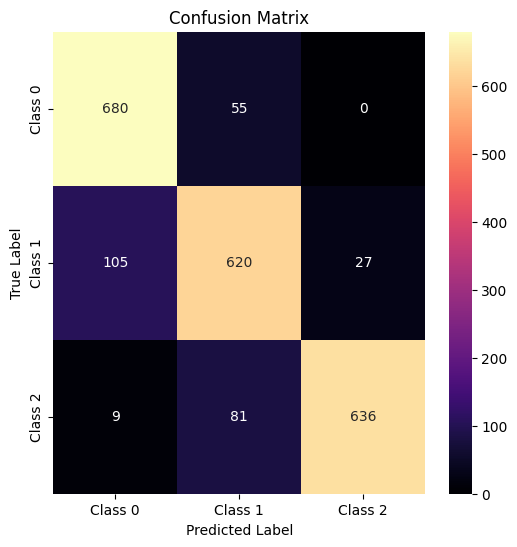

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def evaluate_model(model, val_dataloader, device, class_names=None, cmap="Blues"):
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in val_dataloader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            # Forward pass
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits   # ✅ fix: use .logits

            # Get predicted class labels
            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Convert lists to numpy arrays
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Confusion Matrix
    cm = confusion_matrix(all_labels, all_preds)

    # Plot
    plot_confusion_matrix(cm, class_names, cmap)


def plot_confusion_matrix(cm, class_names=None, cmap="Blues"):
    plt.figure(figsize=(6,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, cbar=True,
                xticklabels=class_names if class_names else np.unique(range(cm.shape[0])),
                yticklabels=class_names if class_names else np.unique(range(cm.shape[0])))
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()


# Example usage:
class_names = ["Class 0", "Class 1", "Class 2"]  # Change based on your dataset
evaluate_model(model, val_dataloader, device, class_names, cmap="magma")  # 🎨 try "Greens", "Purples", "coolwarm"


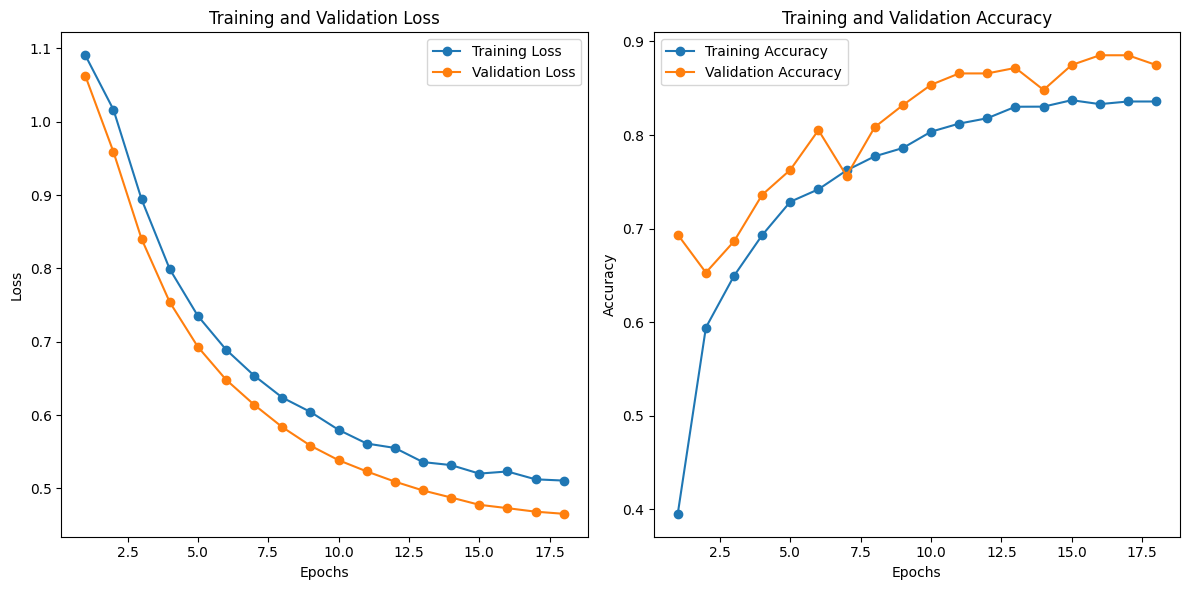

In [ ]:
import matplotlib.pyplot as plt

# Fix: epochs should match the length of the metrics (18)
epochs = list(range(1, 19))

train_loss = [1.0906, 1.0164, 0.8941, 0.7990, 0.7352, 0.6893, 0.6538, 0.6239,
              0.6043, 0.5799, 0.5612, 0.5552, 0.5359, 0.5318, 0.5202, 0.5231, 0.5124, 0.5107]

train_acc = [0.3953, 0.5943, 0.6495, 0.6930, 0.7287, 0.7420, 0.7622, 0.7772,
             0.7861, 0.8035, 0.8122, 0.8179, 0.8302, 0.8303, 0.8372, 0.8330, 0.8358, 0.8358]

val_loss = [1.0626, 0.9588, 0.8401, 0.7540, 0.6930, 0.6483, 0.6141, 0.5836,
            0.5583, 0.5385, 0.5232, 0.5093, 0.4972, 0.4876, 0.4777, 0.4731, 0.4683, 0.4654]

val_acc = [0.6936, 0.6530, 0.6864, 0.7361, 0.7628, 0.8052, 0.7564, 0.8084,
           0.8319, 0.8536, 0.8658, 0.8658, 0.8717, 0.8482, 0.8748, 0.8852, 0.8852, 0.8748]


plt.figure(figsize=(12, 6))

# Plot Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_loss, label='Training Loss', marker='o')
plt.plot(epochs, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(epochs, train_acc, label='Training Accuracy', marker='o')
plt.plot(epochs, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()
